In [11]:
# --- Setup: imports + paths + case metadata + helpers. RUN THIS CELL FIRST. ---
# Self-contained: no _utils.py import; works on any host that has the LASSO repo.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- Auto-discover ROOT: walk up from cwd to find a folder with SCREAM .nc files. ---
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if list(_cand.glob('scream_dpxx_LASSO_SGP_*.nc')):
        ROOT = _cand
        break
else:
    raise FileNotFoundError(
        'Could not locate the LASSO repo root (no scream_dpxx_LASSO_SGP_*.nc found '
        'in cwd or its parents). Launch Jupyter from inside the LASSO repo.'
    )

# --- Case metadata (inlined). 0517/0709/0929 are the three LASSO SGP cases. ---
CASES = {
    '0517': {'date': '2019-05-17', 'sim': 4, 'regime': 'shallow->congestus'},
    '0709': {'date': '2018-07-09', 'sim': 8, 'regime': 'deep convection'},
    '0929': {'date': '2019-09-29', 'sim': 4, 'regime': 'fall transition'},
}
for k, v in CASES.items():
    d = v['date'].replace('-', '')
    v['f_scream']  = ROOT / f"scream_dpxx_LASSO_SGP_{v['date']}.fullfield.AVERAGE.nhours_x1.{v['date']}-43200.nc"
    v['f_mod']     = ROOT / 'WRFandob' / k / f"sgplassomod{v['sim']}C1.m1.{d}.120000.nc"
    v['f_obsmod']  = ROOT / 'WRFandob' / k / f"sgplassodiagobsmod{v['sim']}C1.m1.{d}.120000.nc"
    v['f_obsmodz'] = ROOT / 'WRFandob' / k / f"sgplassodiagobsmodz{v['sim']}C1.m1.{d}.120000.nc"

CASE_ORDER = ['0517', '0709', '0929']
CASE_COLOR = {'0517': '#0072B2', '0709': '#D55E00', '0929': '#009E73'}
FIG_JGR    = ROOT / 'figs' / 'jgr'
FIG_JGR.mkdir(parents=True, exist_ok=True)

UTC_TO_LST = pd.Timedelta(hours=-5)


def to_lst(times):
    """numpy datetime64 (UTC) -> pandas DatetimeIndex in LST (UTC-5)."""
    return pd.DatetimeIndex(times) + UTC_TO_LST


def open_wrf_vap(path):
    """Open a LASSO WRF VAP file. 'height' is dim+var so xarray drops it; reattach as height_km."""
    ds  = xr.open_dataset(path, decode_coords=False, drop_variables=['height'])
    raw = nc.Dataset(path)
    if 'height' in raw.variables:
        ds['height_km'] = (raw.variables['height'].dimensions, raw.variables['height'][:])
    raw.close()
    return ds


def open_case(short):
    """Open all 4 files for one LASSO case. Returns dict with scream/mod/obsmod/obsmodz + date/regime."""
    c = CASES[short]
    return dict(
        case=short, date=c['date'], regime=c['regime'],
        scream=xr.open_dataset(c['f_scream']),
        mod=open_wrf_vap(c['f_mod']),
        obsmod=open_wrf_vap(c['f_obsmod']),
        obsmodz=open_wrf_vap(c['f_obsmodz']),
    )


def assert_source_type(ds_paired):
    """source_type CF flag attrs: idx 0 must be Observation."""
    fm = ds_paired['source_type'].attrs.get('flag_meanings', '?')
    assert 'observation' in fm.lower().split()[0], \
        f'Expected idx 0 = Observation per CF flag attrs, got {fm!r}'
    return fm


def scream_z_agl_km(ds):
    """SCREAM z_mid is AMSL; subtract domain-min bottom to get km AGL (lev, top-first)."""
    z = ds['z_mid'].mean(['time', 'ncol']).values
    return (z - z.min()) / 1000.0


def wrf_z_agl_km(ds):
    """WRF height_km is already km AGL; take time mean for plot axis (bottom-first)."""
    return ds['height_km'].mean('time').values


# Light plot defaults.
plt.rcParams.update({
    'figure.dpi':        130,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
})

print(f'ROOT = {ROOT}')
print(f'Cases ready: {CASE_ORDER}')

ROOT = C:\Users\yij\Documents\Projects\LASSO
Cases ready: ['0517', '0709', '0929']


**Data sources:**

- DP-SCREAM EAMxx v1.0.0, 5 km doubly-periodic, 100 columns × 128 levels, 15 hourly snapshots from 12 UTC.
- WRF-LASSO VAP — obs-constrained LES/reference for SGP.
- ARSCL/MWR — radar-lidar cloud mask and microwave LWP, used as observational evidence

**Three cloud fractions:**

- WRF-LASSO `cloud_fraction` — LES-domain cloud-area fraction (fraction of LES cells with condensate above an internal threshold).
- SCREAM `cldfrac_tot` — parameterised SHOC grid-box cloud-area fraction (not a count of cells).
- ARSCL `cloud_fraction_mask_arscl` — radar/lidar mask; after averaging behaves more like a time-occurrence frequency.


In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc
from matplotlib.patches import Ellipse
# Load all three cases. Each bundle has scream / mod / obsmod / obsmodz + helper arrays.
def hod(times_lst):
    return times_lst.hour + times_lst.minute / 60.0 + times_lst.second / 3600.0

BUNDLES = {short: open_case(short) for short in CASE_ORDER}
for short, b in BUNDLES.items():
    assert_source_type(b['obsmod'])
    b['t_sc']     = to_lst(b['scream']['time'].values)
    b['t_oz']     = to_lst(b['obsmodz']['time'].values)
    b['t_mod']    = to_lst(b['mod']['time'].values)
    b['h_sc']     = hod(b['t_sc'])
    b['h_oz']     = hod(b['t_oz'])
    b['h_mod']    = hod(b['t_mod'])
    b['z_sc_km']  = scream_z_agl_km(b['scream'])
    b['z_wrf_km'] = wrf_z_agl_km(b['obsmodz'])
    print(f"  {short}  {b['date']}")


  0517  2019-05-17
  0709  2018-07-09
  0929  2019-09-29


## Fig 1 — Raw cloud-fraction curtains (SCREAM, WRF-LASSO, ARSCL)

Time–height contour fields on a shared 0–6 km AGL window. Same colour scale (0→1) across all panels: **dark blue = low CF, white = high CF**. Rows are cases in calendar order (May → July → September); columns are SCREAM, WRF-LASSO, ARSCL.


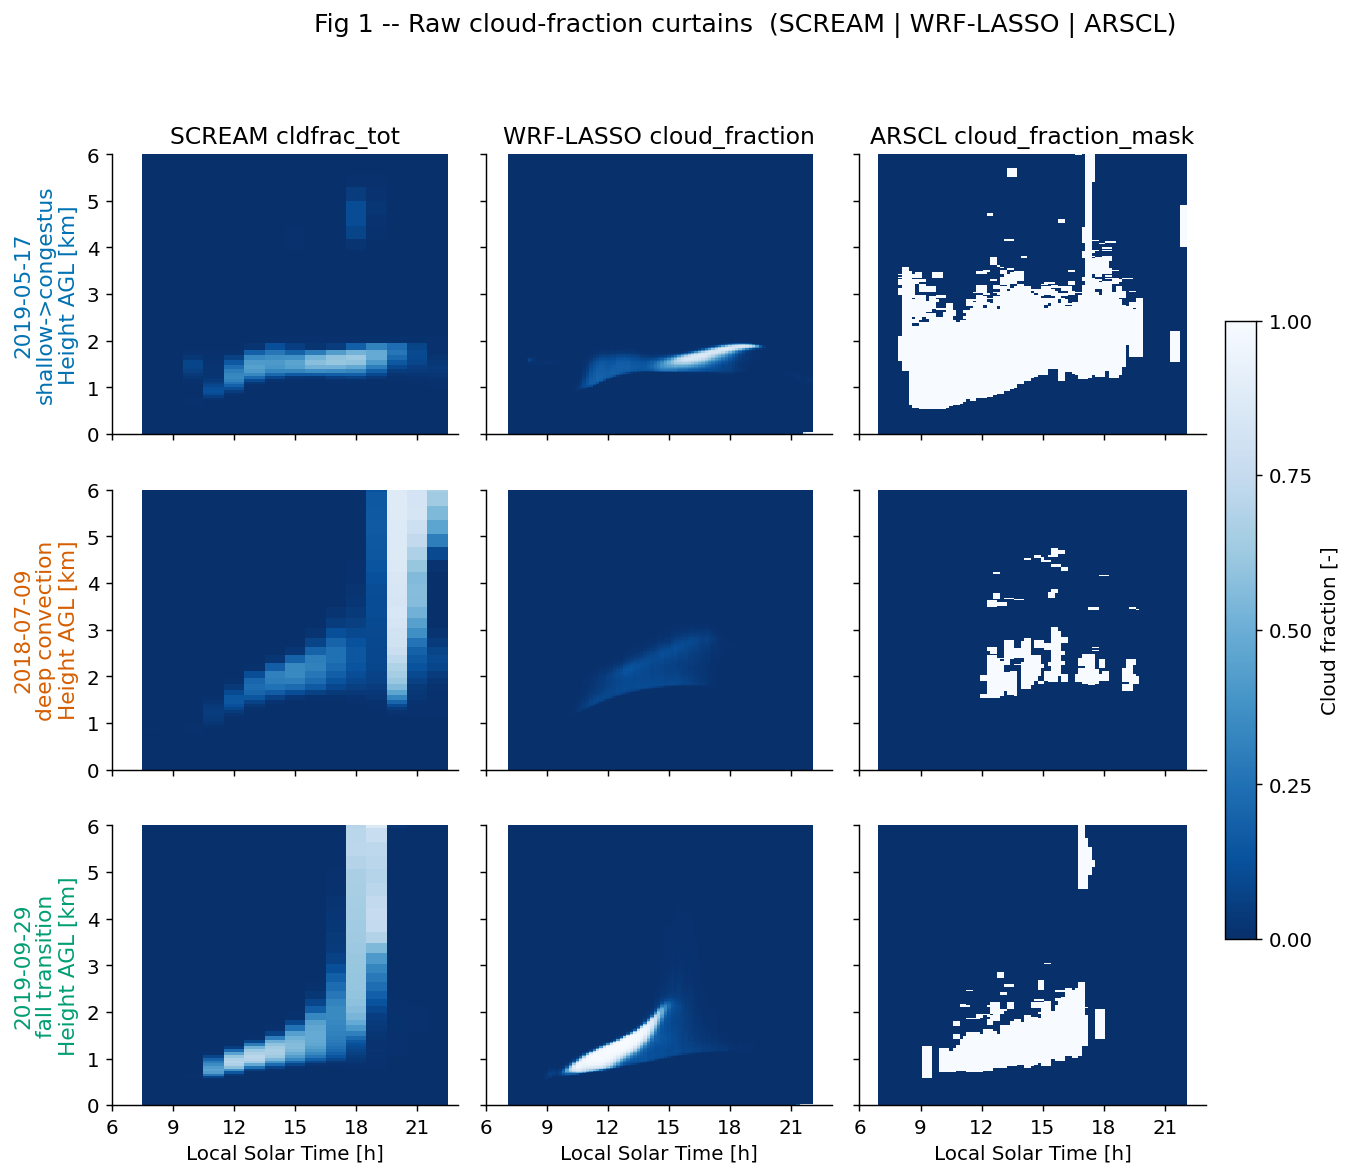

In [3]:
# Fig 1 -- cloud-fraction curtain plots (RAW pixels, Blues_r colormap).
# Layout:
#   rows = cases in calendar order: 0517 (May) / 0709 (July) / 0929 (Sept)
#   cols = SCREAM  / WRF-LASSO  / ARSCL (obs)

Z_TOP_KM = 6.0

fig, axes = plt.subplots(3, 3, figsize=(13.0, 9.5), sharex=True, sharey=True,
                         gridspec_kw=dict(hspace=0.20, wspace=0.08))

for r, short in enumerate(CASE_ORDER):
    b = BUNDLES[short]
    panels = [
        (b['h_sc'], b['z_sc_km'],  b['scream']['cldfrac_tot'].mean('ncol').values.T,    'SCREAM cldfrac_tot'),
        (b['h_oz'], b['z_wrf_km'], b['obsmodz']['cloud_fraction'].values.T,            'WRF-LASSO cloud_fraction'),
        (b['h_oz'], b['z_wrf_km'], b['obsmodz']['cloud_fraction_mask_arscl'].values.T, 'ARSCL cloud_fraction_mask'),
    ]
    for c, (hh, zz, arr, ttl) in enumerate(panels):
        ax = axes[r, c]
        pc = ax.pcolormesh(hh, zz, arr,
                           cmap='Blues_r',
                           vmin=0, vmax=1,
                           shading='auto')
        ax.set_ylim(0, Z_TOP_KM)
        ax.set_xlim(6, 23)
        ax.set_xticks(np.arange(6, 24, 3))
        ax.grid(False)
        if r == 0:
            ax.set_title(ttl, fontsize=13)
        if c == 0:
            ax.set_ylabel(f"{b['date']}\n{b['regime']}\nHeight AGL [km]",
                          color=CASE_COLOR[short], fontsize=12)
        if r == 2:
            ax.set_xlabel('Local Solar Time [h]')

cbar = fig.colorbar(pc, ax=axes, shrink=0.65, pad=0.015,
                    label='Cloud fraction [-]', ticks=[0, 0.25, 0.5, 0.75, 1.0])
fig.suptitle('Fig 1 -- Raw cloud-fraction curtains  (SCREAM | WRF-LASSO | ARSCL)',
             fontsize=14, y=0.995)
plt.show()

## Fig 2 — PBL height (SCREAM) and LCL (WRF)

Boundary-layer / cloud-base context. SCREAM `pbl_height` (domain mean) and WRF `lcl`. These are not directly comparable PBL-height diagnostics;


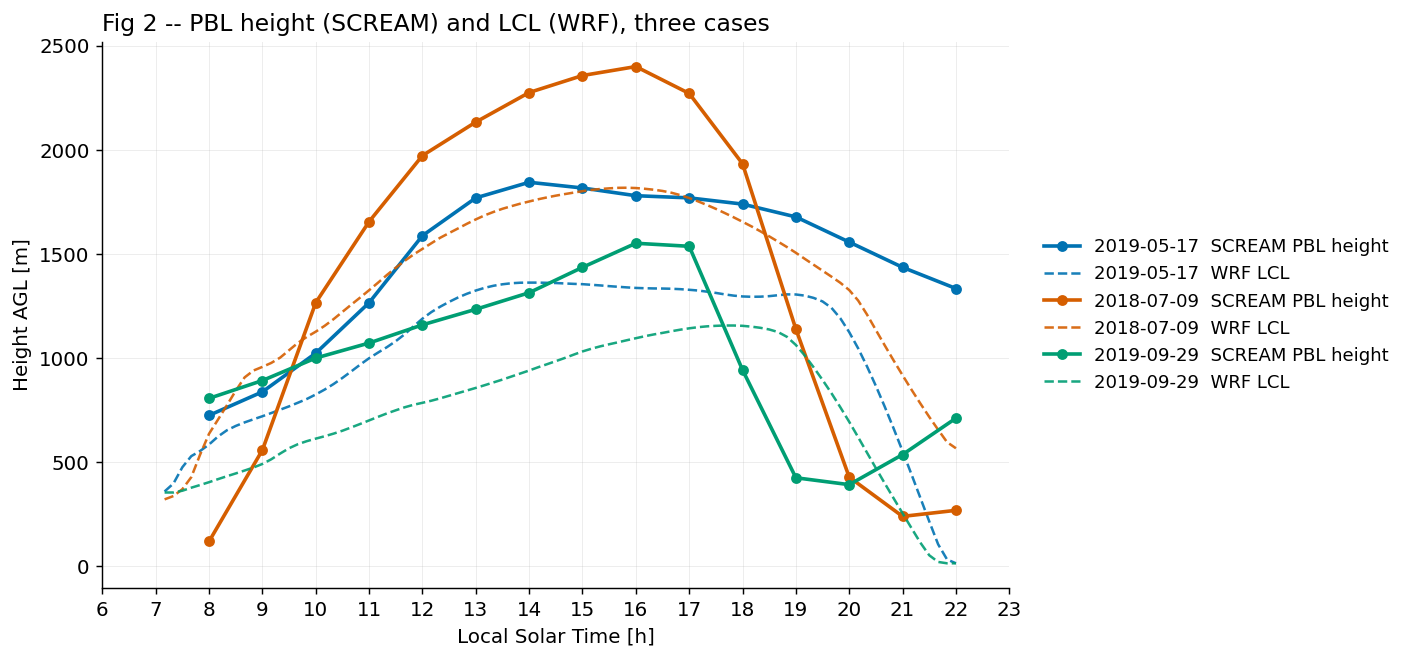

In [4]:
# Fig 2 -- SCREAM PBL height + WRF LCL, 3 cases overlaid on LST hour-of-day.
# Solid = SCREAM domain-mean pbl_height; dashed = WRF lcl. No error band.
fig, ax = plt.subplots(figsize=(11.0, 5.2))
for short in CASE_ORDER:
    b = BUNDLES[short]
    c = CASE_COLOR[short]
    pblh_mean = b['scream']['pbl_height'].mean('ncol').values
    ax.plot(b['h_sc'], pblh_mean, '-o', color=c, ms=5, lw=2.0,
            label=f"{b['date']}  SCREAM PBL height")
    ax.plot(b['h_mod'], b['mod']['lcl'].values, '--', color=c, lw=1.4, alpha=0.9,
            label=f"{b['date']}  WRF LCL")

ax.set_xlim(6, 23)
ax.set_xticks(np.arange(6, 24, 1))
ax.set_xlabel('Local Solar Time [h]')
ax.set_ylabel('Height AGL [m]')
ax.set_title('Fig 2 -- PBL height (SCREAM) and LCL (WRF), three cases',
             loc='left', fontsize=13)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=False, ncol=1, fontsize=10)
plt.tight_layout()
plt.show()


## Fig 3 — Thermodynamic profile context (θ and qᵥ)

Four LST snapshots (09, 12, 15, 18 LST) per case. Top row: potential temperature θ (K). Bottom row: water vapour mixing ratio qᵥ (g kg⁻¹). Solid = SCREAM domain mean, dashed = WRF. Environmental context, maybe useful.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


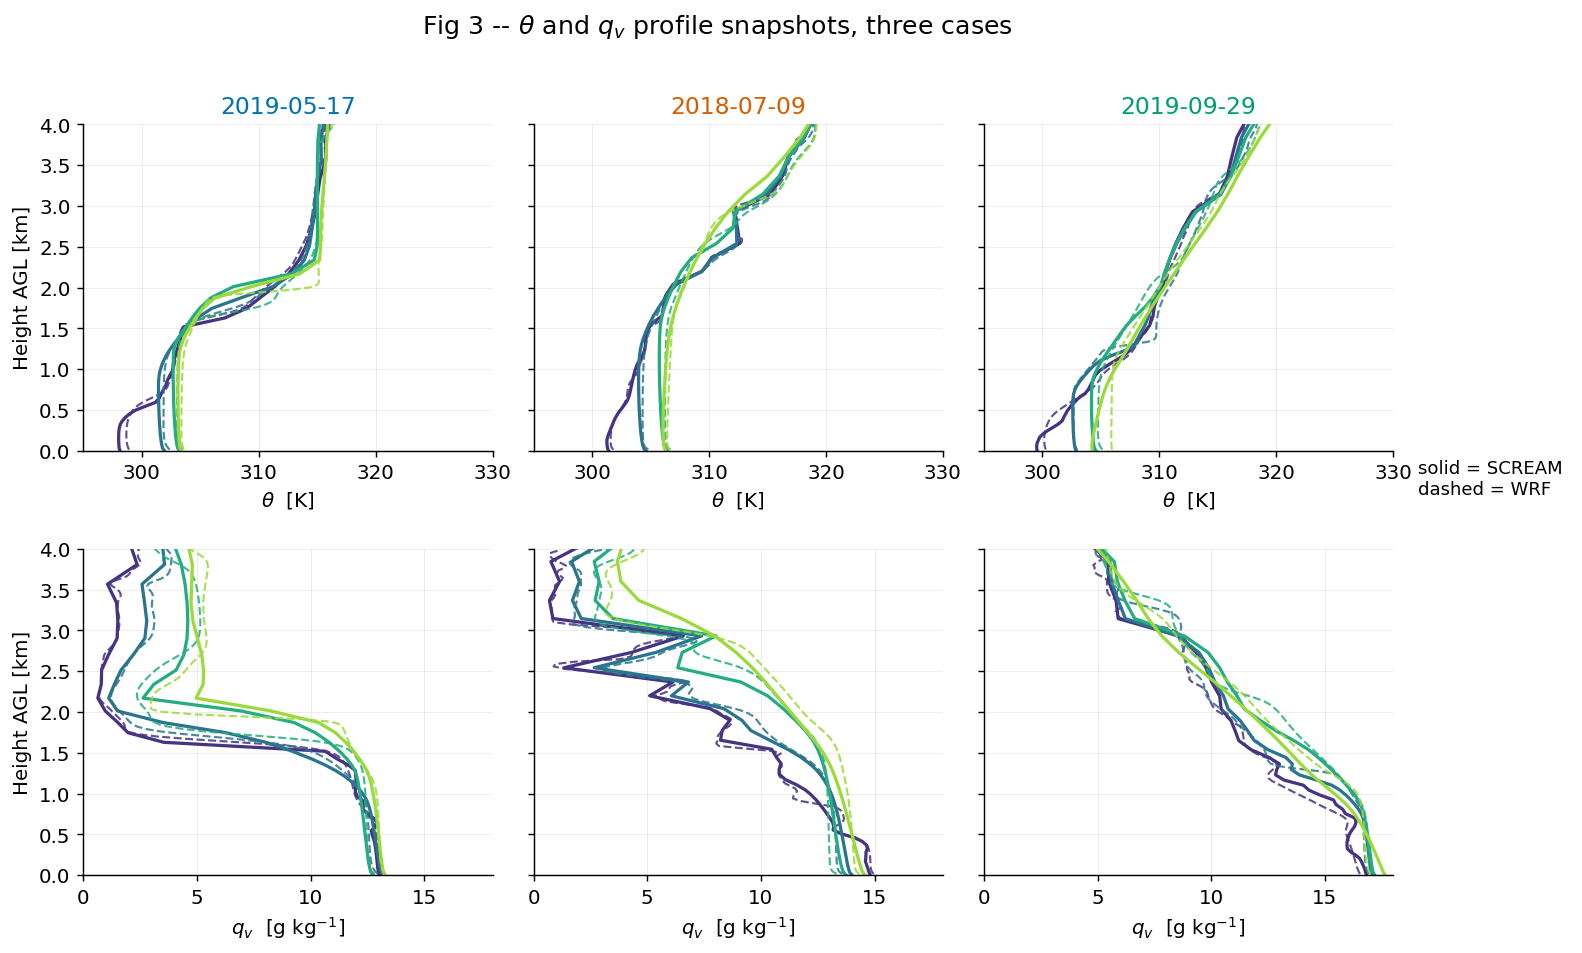

In [5]:
# Fig 3 -- theta and qv profile snapshots. 2 rows (theta / qv) x 3 cols (cases).
SNAP_HOURS = (9, 12, 15, 18)
snap_cmap = plt.colormaps['viridis']
snap_colors = [snap_cmap(0.15 + 0.7 * i / (len(SNAP_HOURS) - 1)) for i in range(len(SNAP_HOURS))]

def nearest_idx(times, target):
    return int(np.argmin(np.abs(times - target)))

fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.5), sharey='row',
                         gridspec_kw=dict(hspace=0.30, wspace=0.10))

for r, var in enumerate(['theta', 'qv']):
    for c, short in enumerate(CASE_ORDER):
        b  = BUNDLES[short]
        sc = b['scream']
        theta_sc  = sc['T_mid'] * (1e5 / sc['p_mid']) ** 0.286
        qv_sc_gkg = sc['qv'] * 1000.0
        ax = axes[r, c]
        snap_lst = [pd.Timestamp(f"{b['date']} {hh:02d}:00") for hh in SNAP_HOURS]
        for ts, col in zip(snap_lst, snap_colors):
            i_sc  = nearest_idx(b['t_sc'],  ts)
            i_mod = nearest_idx(b['t_mod'], ts)
            if var == 'theta':
                prof_sc = theta_sc.isel(time=i_sc).mean('ncol').values
                prof_wf = b['mod']['potential_temp'].isel(time=i_mod).values
            else:
                prof_sc = qv_sc_gkg.isel(time=i_sc).mean('ncol').values
                prof_wf = b['mod']['water_vapor_mixing_ratio'].isel(time=i_mod).values
            label = f'{ts:%H} LST' if (r == 0 and c == 0) else None
            ax.plot(prof_sc, b['z_sc_km'],  '-',  color=col, lw=1.8, label=label)
            ax.plot(prof_wf, b['z_wrf_km'], '--', color=col, lw=1.2, alpha=0.85)
        ax.set_ylim(0, 4)
        if r == 0:
            ax.set_xlim(295, 330)
            ax.set_xlabel(r'$\theta$  [K]')
            ax.set_title(f"{b['date']}", color=CASE_COLOR[short], fontsize=13)
        else:
            ax.set_xlim(0, 18)
            ax.set_xlabel(r'$q_v$  [g kg$^{-1}$]')
        if c == 0:
            ax.set_ylabel('Height AGL [km]')

# Legend out to the right so it never crosses the profiles.
axes[0, 2].legend(loc='center left', bbox_to_anchor=(1.02, -0.10),
                  title='solid = SCREAM\ndashed = WRF',
                  frameon=False, fontsize=10, title_fontsize=10)
fig.suptitle(r'Fig 3 -- $\theta$ and $q_v$ profile snapshots, three cases', y=0.995, fontsize=14)
plt.show()


saved -> C:\Users\yij\Documents\Projects\LASSO\figs\jgr\fig16_lwp_diurnal.png


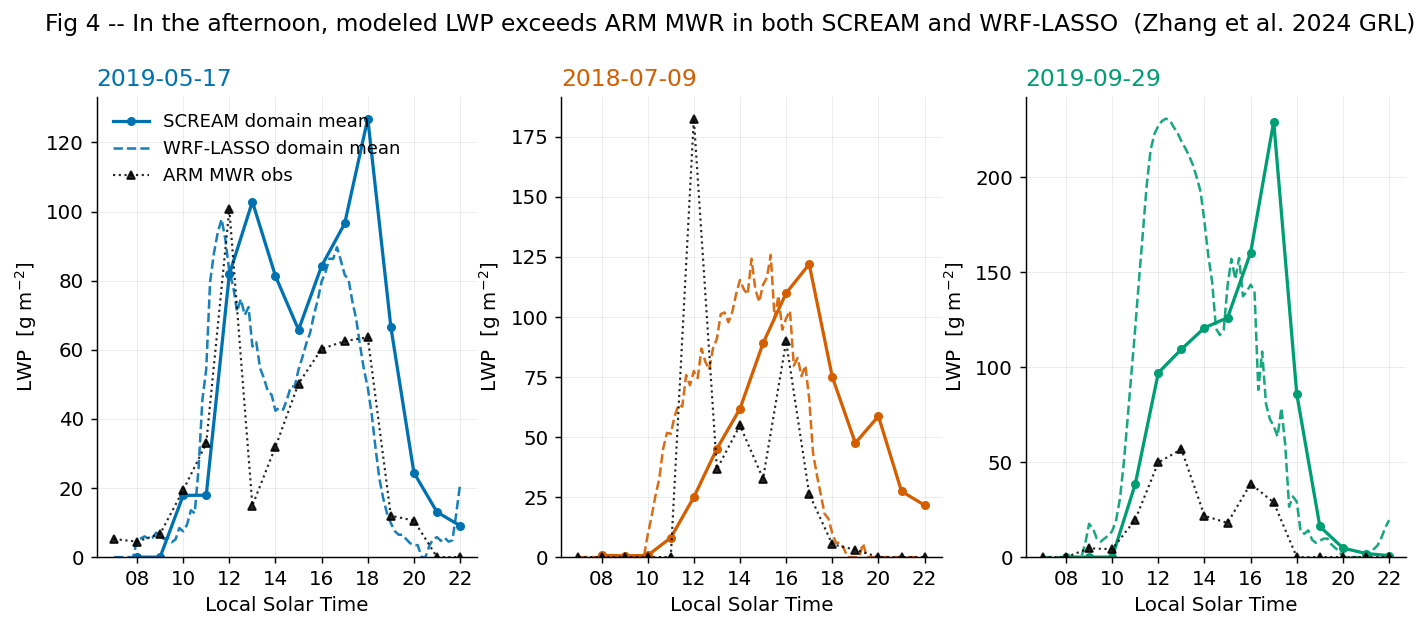

In [6]:
# Fig 4 -- LWP diurnal cycle: SCREAM domain mean, WRF-LASSO domain mean, ARM MWR obs.
# Self-contained: this cell runs independently of the rest of the notebook.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- Auto-discover project root: walk up from cwd until we find SCREAM .nc files. ---
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if list(_cand.glob('scream_dpxx_LASSO_SGP_*.nc')):
        ROOT = _cand
        break
else:
    raise FileNotFoundError(
        'Could not locate the LASSO repo root (no scream_dpxx_LASSO_SGP_*.nc found '
        'in cwd or its parents). Launch Jupyter from inside the LASSO repo.'
    )

CASES = {
    '0517': {'date': '2019-05-17', 'sim': 4},
    '0709': {'date': '2018-07-09', 'sim': 8},
    '0929': {'date': '2019-09-29', 'sim': 4},
}
for k, v in CASES.items():
    d = v['date'].replace('-', '')
    v['f_scream'] = ROOT / f"scream_dpxx_LASSO_SGP_{v['date']}.fullfield.AVERAGE.nhours_x1.{v['date']}-43200.nc"
    v['f_obsmod'] = ROOT / 'WRFandob' / k / f"sgplassodiagobsmod{v['sim']}C1.m1.{d}.120000.nc"
    v['f_mod']    = ROOT / 'WRFandob' / k / f"sgplassomod{v['sim']}C1.m1.{d}.120000.nc"

CASE_ORDER = ['0517', '0709', '0929']
CASE_COLOR = {'0517': '#0072B2', '0709': '#D55E00', '0929': '#009E73'}
FIG_JGR    = ROOT / 'figs' / 'jgr'
FIG_JGR.mkdir(parents=True, exist_ok=True)

UTC_TO_LST = pd.Timedelta(hours=-5)
def to_lst(times):
    return pd.DatetimeIndex(times) + UTC_TO_LST

def open_wrf_vap(path):
    """Open a LASSO WRF VAP file. `height` is both dim and var so xarray drops it; reattach."""
    ds  = xr.open_dataset(path, decode_coords=False, drop_variables=['height'])
    raw = nc.Dataset(path)
    if 'height' in raw.variables:
        ds['height_km'] = (raw.variables['height'].dimensions, raw.variables['height'][:])
    raw.close()
    return ds


# Per-panel autoscale so each peak is fully visible.
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.6), sharey=False,
                         gridspec_kw=dict(wspace=0.22))

for ax, short in zip(axes, CASE_ORDER):
    c   = CASES[short]
    sc  = xr.open_dataset(c['f_scream'])
    mod = open_wrf_vap(c['f_mod'])
    omd = open_wrf_vap(c['f_obsmod'])
    fm = omd['source_type'].attrs.get('flag_meanings', '').lower()
    assert 'observation' in fm.split()[0], f'unexpected source_type for {short}: {fm!r}'

    t_sc  = to_lst(sc['time'].values)
    t_mod = to_lst(mod['time'].values)
    t_omd = to_lst(omd['time'].values)

    lwp_sc  = sc['LiqWaterPath'].mean('ncol').values * 1000.0   # kg/m2 -> g/m2
    lwp_wrf = mod['lwp'].values                                 # g/m2
    lwp_mwr = omd['lwp'].isel(source_type=0).values             # g/m2 (Observation)

    col = CASE_COLOR[short]
    ax.plot(t_sc,  lwp_sc,  '-o', color=col,     ms=4, lw=1.8, label='SCREAM domain mean')
    ax.plot(t_mod, lwp_wrf, '--', color=col,     lw=1.4, alpha=0.9, label='WRF-LASSO domain mean')
    ax.plot(t_omd, lwp_mwr, ':^', color='black', ms=4, lw=1.2, alpha=0.85, label='ARM MWR obs')
    ax.set_title(f"{c['date']}", loc='left', color=col, fontsize=13)
    ax.set_xlabel('Local Solar Time')
    ax.set_ylabel(r'LWP  [g m$^{-2}$]')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.set_ylim(bottom=0)

    sc.close(); mod.close(); omd.close()

axes[0].legend(loc='upper left', frameon=False, fontsize=10)
fig.suptitle('Fig 4 -- In the afternoon, modeled LWP exceeds ARM MWR in both SCREAM and WRF-LASSO  '
             '(Zhang et al. 2024 GRL)',
             fontsize=13, y=1.02)
out_png = FIG_JGR / 'fig16_lwp_diurnal.png'
fig.savefig(out_png, bbox_inches='tight')
print('saved ->', out_png)
plt.show()

## Fig 5 — SCREAM condensate curtain (qc + qi)

Where the actual condensate sits in SCREAM. Domain-mean **qc + qi** (g kg⁻¹) per case, shared colour scale. This motivates the test in Fig 6: if SCREAM's `cldfrac_tot` is high where qc + qi is tiny, the cloud fraction is *diagnostic* rather than backed by real condensate.


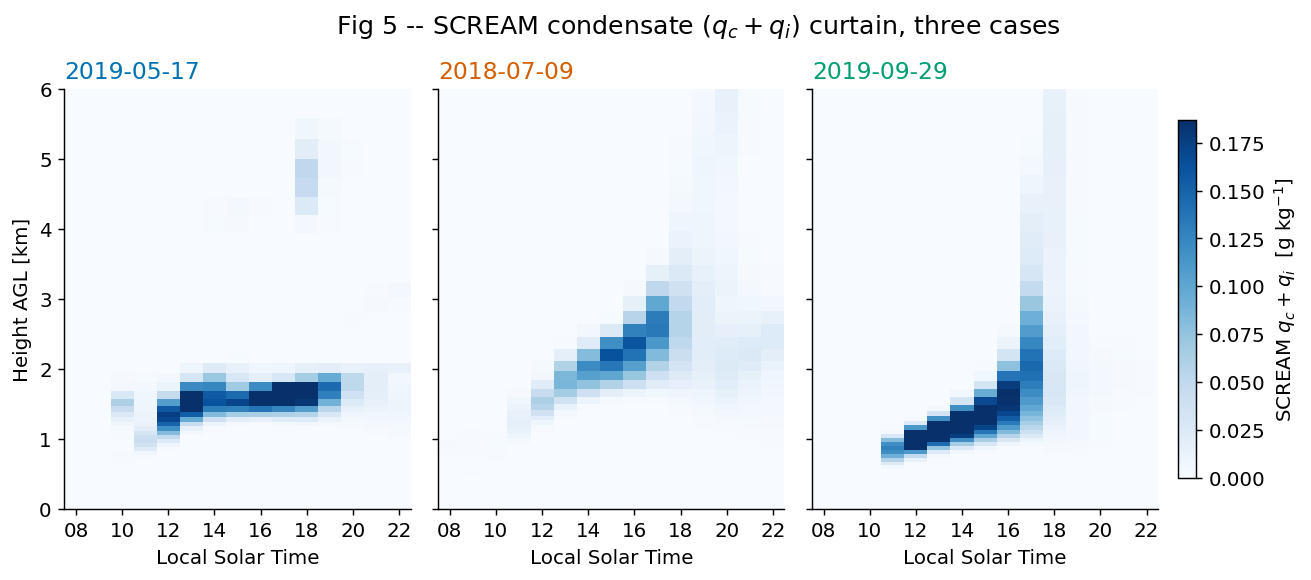

In [7]:
# Fig 5 -- SCREAM condensate (qc + qi) curtain per case, shared color scale.
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2), sharey=True,
                         gridspec_kw=dict(wspace=0.08))

# Pre-compute qc+qi (g/kg) per case; shared vmax = 99th percentile across all three.
cond_arrays = {}
vmaxes = []
for short, b in BUNDLES.items():
    qc = b['scream']['qc'].mean('ncol').values
    qi = b['scream']['qi'].mean('ncol').values if 'qi' in b['scream'] else 0.0 * qc
    cond = (qc + qi) * 1000.0   # -> g/kg
    cond_arrays[short] = cond
    vmaxes.append(np.nanpercentile(cond, 99))
vmax = float(max(max(vmaxes), 0.02))

for ax, short in zip(axes, CASE_ORDER):
    b = BUNDLES[short]
    cond = cond_arrays[short]
    pc = ax.pcolormesh(b['t_sc'], b['z_sc_km'], cond.T,
                       cmap='Blues', vmin=0, vmax=vmax, shading='auto')
    ax.set_ylim(0, 6)
    ax.set_xlabel('Local Solar Time')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.set_title(f"{b['date']}",
                 loc='left', color=CASE_COLOR[short], fontsize=13)
    ax.grid(False)
axes[0].set_ylabel('Height AGL [km]')
cbar = fig.colorbar(pc, ax=axes, shrink=0.85, pad=0.015,
                    label=r'SCREAM $q_c + q_i$  [g kg$^{-1}$]')
fig.suptitle('Fig 5 -- SCREAM condensate ($q_c + q_i$) curtain, three cases', y=1.02, fontsize=14)
plt.show()


## References

- Gustafson, W. I. et al. (2020). The LASSO testbed for shallow convection. *BAMS*. DOI: 10.1175/BAMS-D-19-0065.1Pairs LES output with ARM observations for SGP shallow convection.
- Oue, M. et al. (2016). Multi-instrument cloud-fraction profiles. *GRL*. DOI: 10.1002/2016GL070776. CF profiles are sensitive to sampling and observation geometry.
- Zhang, Y. et al. (2024). LASSO LES cloud–land coupling. *GRL*. DOI: 10.1029/2024GL109774. LWP/CF biases tied to boundary-layer development.
